# DRL-Based Task Offloading in Mobile Edge Computing

**Paper**: Jiang et al., "Deep-Reinforcement-Learning-Based Task Offloading and Resource Allocation in Mobile Edge Computing Network With Heterogeneous Tasks", IEEE Internet of Things Journal, Vol. 12, No. 8, April 2025.

This notebook reproduces all experimental results and figures (Figs. 3-7) from the paper.

## 1. Imports and Setup

In [10]:
%matplotlib inline

In [11]:
import math
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Ensure reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

print("All imports successful.")

All imports successful.


## 2. Configuration Parameters

All tunable parameters for the MEC simulation and DQN agent.

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# PHYSICAL NETWORK LAYOUT
# ═══════════════════════════════════════════════════════════════════════
AREA_SIZE = 600              # Square area side length (metres)
NUM_ENS = 5                  # Number of Edge Nodes (base-stations)

# ═══════════════════════════════════════════════════════════════════════
# WIRELESS COMMUNICATION PARAMETERS
# ═══════════════════════════════════════════════════════════════════════
NUM_CHANNELS = 10            # Orthogonal channels per EN (OFDMA)
CHANNEL_BW = 1e6             # Channel bandwidth (1 MHz)
NOISE_POWER_DBM = -100       # AWGN power (dBm)
NOISE_POWER = 10 ** ((NOISE_POWER_DBM - 30) / 10)  # Convert to Watts
TX_POWER_DBM = 23            # Device uplink transmit power (23 dBm ≈ 0.2 W)
TX_POWER = 10 ** ((TX_POWER_DBM - 30) / 10)
BS_TX_POWER_DBM = 30         # Base-station transmit power (30 dBm = 1 W)
BS_TX_POWER = 10 ** ((BS_TX_POWER_DBM - 30) / 10)
WIRED_RATE = 100e6           # EN-Cloud wired link rate (100 Mbps)

# ═══════════════════════════════════════════════════════════════════════
# COMPUTING CAPACITY
# ═══════════════════════════════════════════════════════════════════════
LOCAL_CPU = 1e9              # Local device CPU (1 GHz)
EN_CPU = 10e9                # Edge Node CPU (10 GHz, shared)
CLOUD_CPU = 20e9             # Cloud server CPU per device (20 GHz)

# ═══════════════════════════════════════════════════════════════════════
# TASK HETEROGENEITY
# ═══════════════════════════════════════════════════════════════════════
TASK_TYPES = {
    0: "text",
    1: "image",
    2: "audio",
    3: "video",
}

# Task size scenarios from Table II
SCENARIOS = {
    "I":   {"text": 50,   "image": 100,  "audio": 200,  "video": 500},
    "II":  {"text": 100,  "image": 200,  "audio": 500,  "video": 1000},
    "III": {"text": 200,  "image": 500,  "audio": 1000, "video": 2000},
    "IV":  {"text": 500,  "image": 1000, "audio": 2000, "video": 5000},
}

# CPU cycles per bit for each task type
CPU_CYCLES_PER_BIT = {
    0: 100,    # text   — lightweight
    1: 200,    # image  — moderate
    2: 300,    # audio  — heavier
    3: 500,    # video  — heaviest
}

# ═══════════════════════════════════════════════════════════════════════
# DQN HYPER-PARAMETERS
# ═══════════════════════════════════════════════════════════════════════
LEARNING_RATE = 1e-3           # Adam optimizer learning rate
DISCOUNT_FACTOR = 0.95         # Discount factor γ
EPSILON_START = 1.0            # Initial exploration rate
EPSILON_END = 0.01             # Minimum exploration rate
EPSILON_DECAY = 0.97           # Epsilon decay per epoch
BATCH_SIZE = 64                # Mini-batch size
MEMORY_SIZE = 20000            # Replay buffer capacity
TARGET_UPDATE_FREQ = 5         # Copy eval→target every k epochs
HIDDEN_DIM = 128               # Neurons per hidden layer
NUM_EPOCHS = 200               # Training epochs
STEPS_PER_EPOCH = 30           # Episodes per epoch

# ═══════════════════════════════════════════════════════════════════════
# ACTION-SPACE DISCRETISATION
# ═══════════════════════════════════════════════════════════════════════
ALPHA_LEVELS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # offloading fractions
BETA_LEVELS  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge fractions

print("Configuration loaded.")

Configuration loaded.


## 3. MEC Environment

Simulates the Mobile Edge Computing network with devices, edge nodes, and cloud.

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# ENVIRONMENT HELPERS
# ═══════════════════════════════════════════════════════════════════════

def path_loss(distance_m: float) -> float:
    """
    Compute channel gain (linear scale) using log-distance model.
    Loss (dB) = 37 + 30 * log10(d)
    Gain = 10^(-loss/10)
    """
    distance_m = max(distance_m, 1.0)
    loss_db = 37.0 + 30.0 * math.log10(distance_m)
    return 10.0 ** (-loss_db / 10.0)


def build_valid_actions(num_channels: int) -> list:
    """
    Build discrete action table: all valid (alpha_idx, beta_idx, channel) triples
    where alpha + beta <= 1.
    """
    actions = []
    for ai, a in enumerate(ALPHA_LEVELS):
        for bi, b in enumerate(BETA_LEVELS):
            if a + b <= 1.0 + 1e-9:
                for ch in range(num_channels):
                    actions.append((ai, bi, ch))
    return actions


# ═══════════════════════════════════════════════════════════════════════
# MEC ENVIRONMENT CLASS
# ═══════════════════════════════════════════════════════════════════════

class MECEnvironment:
    """Simulates the Mobile Edge Computing network."""

    def __init__(self, num_devices: int, scenario: str = "II",
                 task_density: int = 30):
        self.num_devices = num_devices
        self.scenario = scenario
        self.task_density = task_density

        # Place Edge Nodes in grid pattern
        self.en_positions = self._place_ens()

        # Scatter devices uniformly at random
        self.device_positions = np.random.uniform(
            0, AREA_SIZE, (num_devices, 2)
        )

        # Associate each device to nearest EN
        self.device_en = self._associate_devices()

        # Count devices per EN (traffic load)
        self.en_load = np.zeros(NUM_ENS, dtype=int)
        for m in self.device_en:
            self.en_load[m] += 1

        # Pre-compute device-to-EN distances
        self.distances = np.zeros(num_devices)
        for n in range(num_devices):
            m = self.device_en[n]
            self.distances[n] = np.linalg.norm(
                self.device_positions[n] - self.en_positions[m]
            )

        # Discrete actions
        self.valid_actions = build_valid_actions(NUM_CHANNELS)
        self.num_actions = len(self.valid_actions)

        # State dimension: [task_type, data_size, cpu_cycles, ch0_busy, ..., chN_busy]
        self.state_dim = 3 + NUM_CHANNELS

    def _place_ens(self) -> np.ndarray:
        """Distribute ENs roughly evenly in a grid."""
        positions = []
        cols = int(math.ceil(math.sqrt(NUM_ENS)))
        rows = int(math.ceil(NUM_ENS / cols))
        dx = AREA_SIZE / (cols + 1)
        dy = AREA_SIZE / (rows + 1)
        for i in range(NUM_ENS):
            r, c = divmod(i, cols)
            positions.append([(c + 1) * dx, (r + 1) * dy])
        return np.array(positions)

    def _associate_devices(self) -> list:
        """Connect each device to its closest EN."""
        associations = []
        for n in range(self.num_devices):
            dists = np.linalg.norm(
                self.en_positions - self.device_positions[n], axis=1
            )
            associations.append(int(np.argmin(dists)))
        return associations

    def reset(self) -> np.ndarray:
        """Start a new episode: generate random tasks for all devices."""
        self.tasks = []
        scenario_sizes = SCENARIOS[self.scenario]

        for n in range(self.num_devices):
            task_type = random.randint(0, 3)
            type_name = TASK_TYPES[task_type]

            # Base size with ±20% jitter
            data_size_kb = scenario_sizes[type_name] * random.uniform(0.8, 1.2)
            data_size_bits = data_size_kb * 1024 * 8

            cpu_cycles = data_size_bits * CPU_CYCLES_PER_BIT[task_type]

            self.tasks.append({
                "type": task_type,
                "data_bits": data_size_bits,
                "cpu_cycles": cpu_cycles,
            })

        # Channel state per EN
        self.channel_state = {
            m: np.zeros(NUM_CHANNELS) for m in range(NUM_ENS)
        }
        return self._get_state(0)

    def _get_state(self, device_idx: int) -> np.ndarray:
        """Build observation vector for device device_idx."""
        task = self.tasks[device_idx]
        m = self.device_en[device_idx]

        data_norm = task["data_bits"] / 1e8
        cpu_norm  = task["cpu_cycles"] / 1e12
        ch_state  = self.channel_state[m].copy()

        state = np.concatenate([
            [task["type"] / 3.0, data_norm, cpu_norm],
            ch_state,
        ])
        return state.astype(np.float32)

    def step(self, device_idx: int, action_idx: int):
        """Execute action for device and return (next_state, reward, done, latency)."""
        ai, bi, ch = self.valid_actions[action_idx]
        alpha = ALPHA_LEVELS[ai]
        beta  = BETA_LEVELS[bi]
        gamma = max(0.0, 1.0 - alpha - beta)

        task   = self.tasks[device_idx]
        m      = self.device_en[device_idx]
        d_bits = task["data_bits"]
        p_cpu  = task["cpu_cycles"]
        dist   = self.distances[device_idx]

        self.channel_state[m][ch] = 1.0

        latency = self._compute_latency(
            device_idx, m, d_bits, p_cpu, dist, alpha, beta, gamma
        )

        reward = -latency

        done = (device_idx >= self.num_devices - 1)
        if not done:
            next_state = self._get_state(device_idx + 1)
        else:
            next_state = np.zeros(self.state_dim, dtype=np.float32)

        return next_state, reward, done, latency

    def compute_latency_for_action(self, device_idx: int,
                                   alpha: float, beta: float,
                                   gamma: float, channel: int) -> float:
        """Public method for baselines: compute latency from continuous α,β,γ."""
        task   = self.tasks[device_idx]
        m      = self.device_en[device_idx]
        d_bits = task["data_bits"]
        p_cpu  = task["cpu_cycles"]
        dist   = self.distances[device_idx]
        return self._compute_latency(
            device_idx, m, d_bits, p_cpu, dist, alpha, beta, gamma
        )

    def _compute_latency(self, device_idx, m, d_bits, p_cpu, dist,
                        alpha, beta, gamma) -> float:
        """Core latency model (Eqs. 6-13 from paper)."""
        # Uplink transmission rate (SINR, Shannon capacity)
        gain = path_loss(dist)
        interference = 0.0
        for j in range(NUM_ENS):
            if j != m:
                d_j = np.linalg.norm(
                    self.en_positions[j] - self.device_positions[device_idx]
                )
                interference += BS_TX_POWER * path_loss(d_j)

        sinr    = TX_POWER * gain / (interference + NOISE_POWER)
        rate_up = CHANNEL_BW * math.log2(1 + sinr)

        # Communication delays
        if rate_up > 0 and (beta + gamma) > 0:
            t_comm_en = (beta + gamma) * d_bits / rate_up
        else:
            t_comm_en = 0.0

        t_comm_cloud = (gamma * d_bits / WIRED_RATE) if gamma > 0 else 0.0

        # Computation delays
        t_local = (alpha * p_cpu / LOCAL_CPU) if alpha > 0 else 0.0

        load_m = max(self.en_load[m], 1)
        t_en = (beta * p_cpu * load_m / EN_CPU) if beta > 0 else 0.0

        t_cloud = (gamma * p_cpu / CLOUD_CPU) if gamma > 0 else 0.0

        # Per-path totals
        t_L = t_local
        t_E = t_comm_en + t_en
        t_C = t_comm_en + t_comm_cloud + t_cloud

        # Overall completion (parallel execution, max across paths)
        return max(t_L, t_E, t_C)


print("MEC Environment initialized.")

MEC Environment initialized.


## 4. Deep Q-Network Agent

Neural network-based agent for learning optimal offloading policies.

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# Q-NETWORK NEURAL NETWORK
# ═══════════════════════════════════════════════════════════════════════

class QNetwork(nn.Module):
    """Fully-connected network mapping state → Q-values for each action."""

    def __init__(self, state_dim: int, action_dim: int,
                 hidden: int = HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ═══════════════════════════════════════════════════════════════════════
# EXPERIENCE REPLAY MEMORY
# ═══════════════════════════════════════════════════════════════════════

class ReplayMemory:
    """Fixed-size FIFO buffer for storing experience tuples."""

    def __init__(self, capacity: int = MEMORY_SIZE):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


# ═══════════════════════════════════════════════════════════════════════
# DQN AGENT
# ═══════════════════════════════════════════════════════════════════════

class DQNAgent:
    """Deep Q-Network agent for MEC offloading."""

    def __init__(self, state_dim: int, num_actions: int,
                 device: str = "cpu"):
        self.num_actions = num_actions
        self.device = device

        self.epsilon = EPSILON_START

        # Evaluate and target networks
        self.eval_net   = QNetwork(state_dim, num_actions).to(device)
        self.target_net = QNetwork(state_dim, num_actions).to(device)
        self.target_net.load_state_dict(self.eval_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.eval_net.parameters(), lr=LEARNING_RATE)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=100, gamma=0.5
        )
        self.memory    = ReplayMemory(MEMORY_SIZE)
        self.loss_fn   = nn.MSELoss()

    def select_action(self, state: np.ndarray, greedy: bool = False) -> int:
        """ε-greedy action selection."""
        if not greedy and random.random() < self.epsilon:
            return random.randrange(self.num_actions)

        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.eval_net(state_t)
            return int(q_values.argmax(dim=1).item())

    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def update(self) -> float:
        """One gradient descent step on MSE loss."""
        if len(self.memory) < BATCH_SIZE:
            return 0.0

        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        states_t      = torch.FloatTensor(states).to(self.device)
        actions_t     = torch.LongTensor(actions).to(self.device)
        rewards_t     = torch.FloatTensor(rewards).to(self.device)
        next_states_t = torch.FloatTensor(next_states).to(self.device)
        dones_t       = torch.FloatTensor(dones).to(self.device)

        # Normalize rewards within batch
        reward_std = rewards_t.std() + 1e-8
        rewards_t = (rewards_t - rewards_t.mean()) / reward_std

        q_values = self.eval_net(states_t) \
            .gather(1, actions_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(dim=1)[0]
            target = rewards_t + DISCOUNT_FACTOR * next_q * (1 - dones_t)

        loss = self.loss_fn(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.eval_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        return loss.item()

    def update_target(self):
        """Sync target network with eval network."""
        self.target_net.load_state_dict(self.eval_net.state_dict())

    def decay_epsilon(self):
        """Decay exploration rate and step LR scheduler."""
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)
        self.scheduler.step()


print("DQN Agent initialized.")

DQN Agent initialized.


## 5. Baseline Algorithms

Three comparison baselines: Random, Tabular Q-Learning, and Genetic Algorithm.

In [15]:
# ═══════════════════════════════════════════════════════════════════════
# RANDOM BASELINE
# ═══════════════════════════════════════════════════════════════════════

def evaluate_random(env) -> float:
    """Random offloading: uniform random α, β, channel."""
    env.reset()
    total_latency = 0.0

    for n in range(env.num_devices):
        alpha = random.random()
        beta  = random.random() * (1.0 - alpha)
        gamma = 1.0 - alpha - beta
        ch    = random.randint(0, NUM_CHANNELS - 1)

        latency = env.compute_latency_for_action(n, alpha, beta, gamma, ch)
        total_latency += latency

    return total_latency / env.num_devices


# ═══════════════════════════════════════════════════════════════════════
# TABULAR Q-LEARNING BASELINE
# ═══════════════════════════════════════════════════════════════════════

def evaluate_qlearning(env, num_episodes: int = 200) -> float:
    """Tabular Q-learning with discretized states and actions."""
    # Build action list
    q_actions = []
    for a in ALPHA_LEVELS:
        for b in BETA_LEVELS:
            if a + b <= 1.0 + 1e-9:
                for ch in range(NUM_CHANNELS):
                    q_actions.append((a, b, ch))
    num_q_actions = len(q_actions)

    # Q-table: 16 states (4 types × 4 size buckets)
    num_states = 16
    Q_table = np.zeros((num_states, num_q_actions))

    lr  = 0.1    # learning rate
    gam = 0.9    # discount factor
    eps = 1.0    # exploration rate

    def state_to_idx(task_type: int, data_bits: float) -> int:
        """Map (task_type, data_size) to discrete state index."""
        size_kb = data_bits / (1024 * 8)
        if size_kb < 150:
            bucket = 0
        elif size_kb < 500:
            bucket = 1
        elif size_kb < 1500:
            bucket = 2
        else:
            bucket = 3
        return task_type * 4 + bucket

    # Training loop
    for ep in range(num_episodes):
        env.reset()

        for n in range(env.num_devices):
            task  = env.tasks[n]
            s_idx = state_to_idx(task["type"], task["data_bits"])

            if random.random() < eps:
                a_idx = random.randrange(num_q_actions)
            else:
                a_idx = int(np.argmax(Q_table[s_idx]))

            alpha, beta, ch = q_actions[a_idx]
            gamma_val = max(0.0, 1.0 - alpha - beta)
            latency   = env.compute_latency_for_action(
                n, alpha, beta, gamma_val, ch
            )
            reward = -latency

            if n < env.num_devices - 1:
                next_task = env.tasks[n + 1]
                s_next    = state_to_idx(next_task["type"], next_task["data_bits"])
                Q_table[s_idx, a_idx] += lr * (
                    reward + gam * np.max(Q_table[s_next])
                    - Q_table[s_idx, a_idx]
                )
            else:
                Q_table[s_idx, a_idx] += lr * (
                    reward - Q_table[s_idx, a_idx]
                )

        eps = max(0.01, eps * 0.99)

    # Evaluate with greedy policy
    env.reset()
    total_latency = 0.0

    for n in range(env.num_devices):
        task  = env.tasks[n]
        s_idx = state_to_idx(task["type"], task["data_bits"])
        a_idx = int(np.argmax(Q_table[s_idx]))

        alpha, beta, ch = q_actions[a_idx]
        gamma_val = max(0.0, 1.0 - alpha - beta)
        latency   = env.compute_latency_for_action(
            n, alpha, beta, gamma_val, ch
        )
        total_latency += latency

    return total_latency / env.num_devices


# ═══════════════════════════════════════════════════════════════════════
# GENETIC ALGORITHM BASELINE
# ═══════════════════════════════════════════════════════════════════════

def evaluate_ga(env, pop_size: int = 30, generations: int = 50,
               gene_len: int = 32) -> float:
    """Heuristic search using binary-coded Genetic Algorithm."""
    env.reset()
    num_d = env.num_devices
    bits_per_var = gene_len // 2
    total_bits   = num_d * gene_len

    def decode(individual: list) -> list:
        """Convert binary genome to (alpha, beta, gamma) per device."""
        decisions = []
        for n in range(num_d):
            start = n * gene_len
            alpha_bits = individual[start : start + bits_per_var]
            alpha = int("".join(map(str, alpha_bits)), 2) / (2**bits_per_var - 1)

            beta_bits = individual[start + bits_per_var : start + gene_len]
            beta_raw  = int("".join(map(str, beta_bits)), 2) / (2**bits_per_var - 1)
            beta  = beta_raw * (1.0 - alpha)
            gamma = 1.0 - alpha - beta

            decisions.append((alpha, beta, gamma))
        return decisions

    def fitness(individual: list) -> float:
        decisions = decode(individual)
        total = 0.0
        for n in range(num_d):
            a, b, g = decisions[n]
            ch = n % NUM_CHANNELS
            total += env.compute_latency_for_action(n, a, b, g, ch)
        return -total

    # Initialize population
    population = [
        np.random.randint(0, 2, total_bits).tolist()
        for _ in range(pop_size)
    ]

    # Evolution loop
    for gen in range(generations):
        scored = [(fitness(ind), ind) for ind in population]
        scored.sort(key=lambda x: x[0], reverse=True)

        elite_count = max(2, pop_size // 10)
        new_pop = [s[1] for s in scored[:elite_count]]

        while len(new_pop) < pop_size:
            p1 = random.choice(new_pop[:elite_count])
            p2 = random.choice(new_pop[:elite_count])

            cx = random.randint(1, total_bits - 1)
            child = p1[:cx] + p2[cx:]

            for i in range(len(child)):
                if random.random() < 0.01:
                    child[i] = 1 - child[i]

            new_pop.append(child)

        population = new_pop

    # Evaluate best on fresh environment
    best = max(population, key=fitness)
    decisions = decode(best)

    eval_env = MECEnvironment(num_d, env.scenario, env.task_density)
    eval_env.reset()
    total_latency = 0.0
    for n in range(num_d):
        a, b, g = decisions[n]
        ch = n % NUM_CHANNELS
        total_latency += eval_env.compute_latency_for_action(n, a, b, g, ch)

    return total_latency / num_d


print("Baseline algorithms initialized.")

Baseline algorithms initialized.


## 6. Plotting Functions

Matplotlib functions to generate figures 3-7.

In [16]:
def plot_loss_convergence(loss_history: list):
    """Plot DQN training loss over epochs (Fig. 3)."""
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, linewidth=1.2, color="tab:blue")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Fig. 3: Convergence of Loss Function During DQN Training")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_reward_convergence(reward_history: list):
    """Plot DQN reward convergence over epochs (Fig. 4)."""
    plt.figure(figsize=(8, 5))
    plt.plot(reward_history, linewidth=1.2, color="tab:orange")
    plt.xlabel("Epoch")
    plt.ylabel("Reward (negative latency)")
    plt.title("Fig. 4: Reward Convergence Analysis of DQN")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_scheme_comparison(results: dict):
    """Bar chart comparing all schemes (Fig. 5)."""
    schemes = list(results.keys())
    values  = [results[s] for s in schemes]
    colors  = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(schemes, values, color=colors[:len(schemes)], width=0.5)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.4f}", ha="center", va="bottom", fontsize=9,
        )

    plt.ylabel("Average Latency (s)")
    plt.title("Fig. 5: Average Latency Under Different Schemes")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_scenario_comparison(scenario_results: dict):
    """Grouped bar chart across scenarios (Fig. 6)."""
    scenarios = list(scenario_results.keys())
    schemes   = list(scenario_results[scenarios[0]].keys())
    x         = np.arange(len(scenarios))
    width     = 0.18
    colors    = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    plt.figure(figsize=(10, 6))
    for i, scheme in enumerate(schemes):
        vals = [scenario_results[sc][scheme] for sc in scenarios]
        plt.bar(x + i * width, vals, width, label=scheme, color=colors[i])

    plt.xticks(x + width * 1.5, [f"Scenario {s}" for s in scenarios])
    plt.ylabel("Average Latency (s)")
    plt.title("Fig. 6: Average Latency Versus Scenario")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_density_comparison(density_results: dict):
    """Line plot across task densities (Fig. 7)."""
    densities = sorted(density_results.keys())
    schemes   = list(density_results[densities[0]].keys())
    markers   = ["o", "s", "^", "D"]
    colors    = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    plt.figure(figsize=(10, 6))
    for i, scheme in enumerate(schemes):
        vals = [density_results[d][scheme] for d in densities]
        plt.plot(
            densities, vals,
            marker=markers[i], label=scheme,
            color=colors[i], linewidth=1.5, markersize=6,
        )

    plt.xlabel("Task Density (tasks per 100 s)")
    plt.ylabel("Average Latency (s)")
    plt.title("Fig. 7: Average Latency Versus Task Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


print("Plotting functions initialized.")

Plotting functions initialized.


## 7. Training and Evaluation Functions

In [17]:
def train_dqn(env: MECEnvironment,
             num_epochs: int = NUM_EPOCHS,
             steps_per_epoch: int = STEPS_PER_EPOCH,
             verbose: bool = True):
    """
    Train a DQN agent on the given MEC environment.

    Returns (agent, loss_history, reward_history).
    """
    agent = DQNAgent(env.state_dim, env.num_actions)
    loss_history   = []
    reward_history = []

    for epoch in range(num_epochs):
        epoch_loss   = 0.0
        epoch_reward = 0.0
        loss_count   = 0

        for step in range(steps_per_epoch):
            env.reset()
            episode_reward = 0.0

            for n in range(env.num_devices):
                state  = env._get_state(n)
                action = agent.select_action(state)
                next_state, reward, done, _ = env.step(n, action)
                agent.store(state, action, reward, next_state, done)
                episode_reward += reward

            loss = agent.update()
            epoch_loss += loss
            loss_count += 1
            epoch_reward += episode_reward

        agent.decay_epsilon()
        if (epoch + 1) % TARGET_UPDATE_FREQ == 0:
            agent.update_target()

        avg_loss   = epoch_loss / max(loss_count, 1)
        avg_reward = epoch_reward / steps_per_epoch
        loss_history.append(avg_loss)
        reward_history.append(avg_reward)

        if verbose and (epoch + 1) % 50 == 0:
            print(f"    Epoch {epoch+1}/{num_epochs}  "
                  f"Loss: {avg_loss:.4f}  "
                  f"Reward: {avg_reward:.2f}  "
                  f"ε: {agent.epsilon:.4f}")

    return agent, loss_history, reward_history


def evaluate_dqn(env: MECEnvironment, agent: DQNAgent) -> float:
    """Run trained DQN greedily on fresh environment."""
    env.reset()
    total_latency = 0.0

    for n in range(env.num_devices):
        state = env._get_state(n)
        action = agent.select_action(state, greedy=True)
        _, _, _, latency = env.step(n, action)
        total_latency += latency

    return total_latency / env.num_devices


def evaluate_all_schemes(agent, scenario, num_devices, task_density,
                        num_runs=3):
    """
    Run each of the four schemes num_runs times.
    Returns dict: {"Random": float, "Q-Learning": float, "GA": float, "DQN": float}
    """
    results = {"Random": 0.0, "Q-Learning": 0.0, "GA": 0.0, "DQN": 0.0}

    for _ in range(num_runs):
        env_r = MECEnvironment(num_devices, scenario, task_density)
        results["Random"] += evaluate_random(env_r)

        env_q = MECEnvironment(num_devices, scenario, task_density)
        results["Q-Learning"] += evaluate_qlearning(env_q, num_episodes=150)

        env_g = MECEnvironment(num_devices, scenario, task_density)
        results["GA"] += evaluate_ga(env_g)

        env_d = MECEnvironment(num_devices, scenario, task_density)
        results["DQN"] += evaluate_dqn(env_d, agent)

    for k in results:
        results[k] /= num_runs

    return results


print("Training and evaluation functions initialized.")

Training and evaluation functions initialized.


## 8. Main Experiment Pipeline

Running all four experiments to reproduce figures 3-7.

Experiment 1: DQN Training Convergence (Figs. 3 & 4)
    Epoch 50/200  Loss: 1.3091  Reward: -95.24  ε: 0.2181
    Epoch 100/200  Loss: 2.0168  Reward: -54.14  ε: 0.0476
    Epoch 150/200  Loss: 1.2468  Reward: -42.53  ε: 0.0104
    Epoch 200/200  Loss: 1.0907  Reward: -46.01  ε: 0.0100


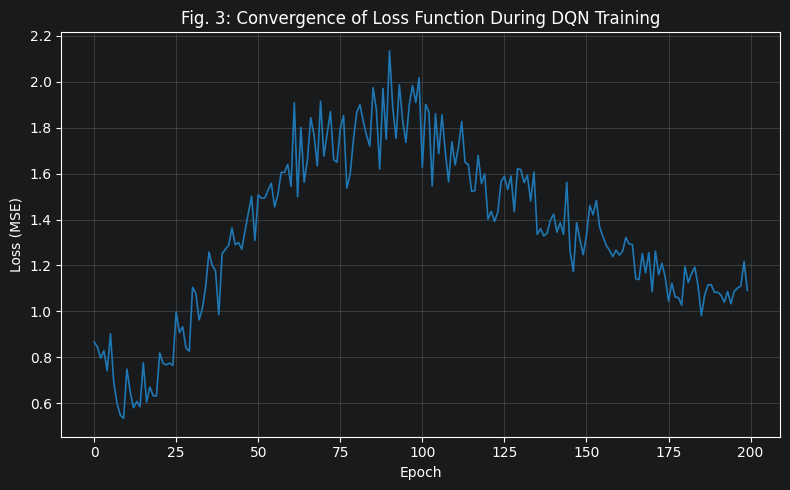

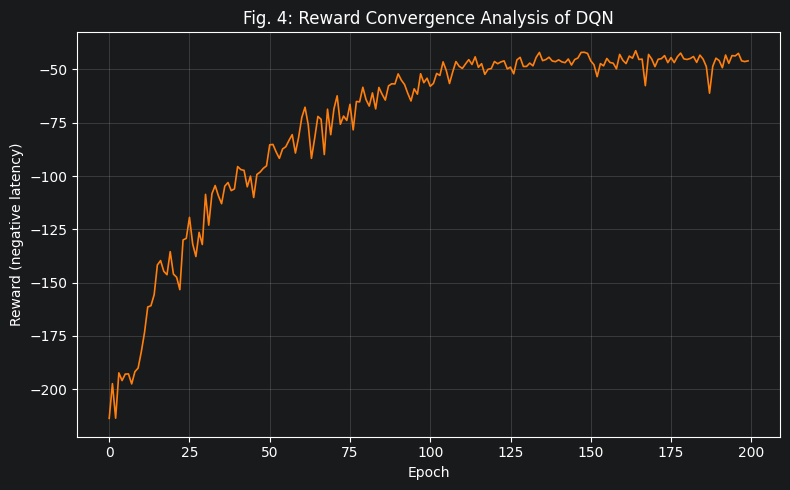

In [18]:
num_devices = 30

# ═════════════════════════════════════════════════════════════════════
# Experiment 1: DQN Training Convergence (Figs. 3 & 4)
# ═════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Experiment 1: DQN Training Convergence (Figs. 3 & 4)")
print("=" * 60)

env = MECEnvironment(num_devices, scenario="II", task_density=30)
agent, loss_history, reward_history = train_dqn(env)

plot_loss_convergence(loss_history)
plot_reward_convergence(reward_history)


Experiment 2: Scheme Comparison (Fig. 5)
  Random      : 4.7296 s
  Q-Learning  : 3.5199 s
  GA          : 1.7364 s
  DQN         : 1.4699 s


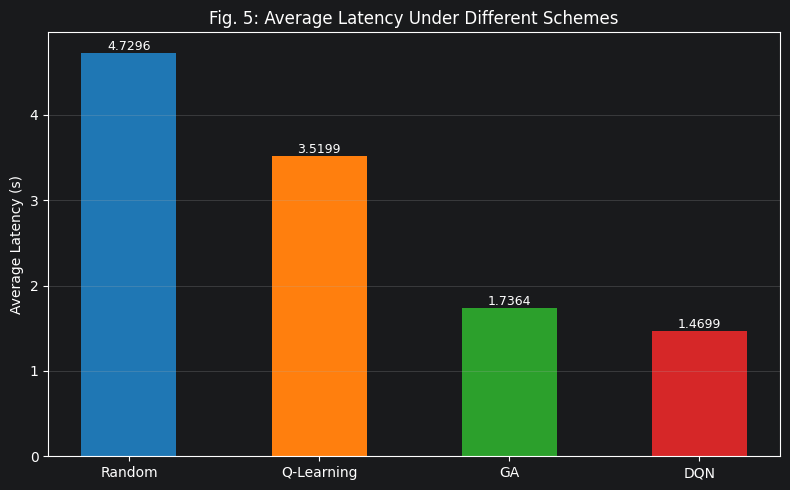

In [19]:
# ═════════════════════════════════════════════════════════════════════
# Experiment 2: Scheme Comparison (Fig. 5)
# ═════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("Experiment 2: Scheme Comparison (Fig. 5)")
print("=" * 60)

scheme_results = evaluate_all_schemes(
    agent, scenario="II", num_devices=num_devices,
    task_density=30, num_runs=5,
)
for name, val in scheme_results.items():
    print(f"  {name:12s}: {val:.4f} s")

plot_scheme_comparison(scheme_results)


Experiment 3: Scenario Comparison (Fig. 6)

  --- Scenario I ---
    Epoch 50/200  Loss: 1.5332  Reward: -50.30  ε: 0.2181
    Epoch 100/200  Loss: 2.5605  Reward: -27.78  ε: 0.0476
    Epoch 150/200  Loss: 1.5307  Reward: -22.04  ε: 0.0104
    Epoch 200/200  Loss: 1.1184  Reward: -21.60  ε: 0.0100
  Results: {Random: 1.7627, Q-Learning: 2.2577, GA: 1.0098, DQN: 0.7155}

  --- Scenario II ---
    Epoch 50/200  Loss: 1.1867  Reward: -75.00  ε: 0.2181
    Epoch 100/200  Loss: 1.7190  Reward: -51.17  ε: 0.0476
    Epoch 150/200  Loss: 1.2026  Reward: -41.81  ε: 0.0104
    Epoch 200/200  Loss: 1.1238  Reward: -41.55  ε: 0.0100
  Results: {Random: 4.4311, Q-Learning: 1.8886, GA: 2.0121, DQN: 1.3888}

  --- Scenario III ---
    Epoch 50/200  Loss: 1.5149  Reward: -195.52  ε: 0.2181
    Epoch 100/200  Loss: 2.0841  Reward: -112.51  ε: 0.0476
    Epoch 150/200  Loss: 1.8102  Reward: -96.09  ε: 0.0104
    Epoch 200/200  Loss: 1.1450  Reward: -88.44  ε: 0.0100
  Results: {Random: 10.5276, Q-Lea

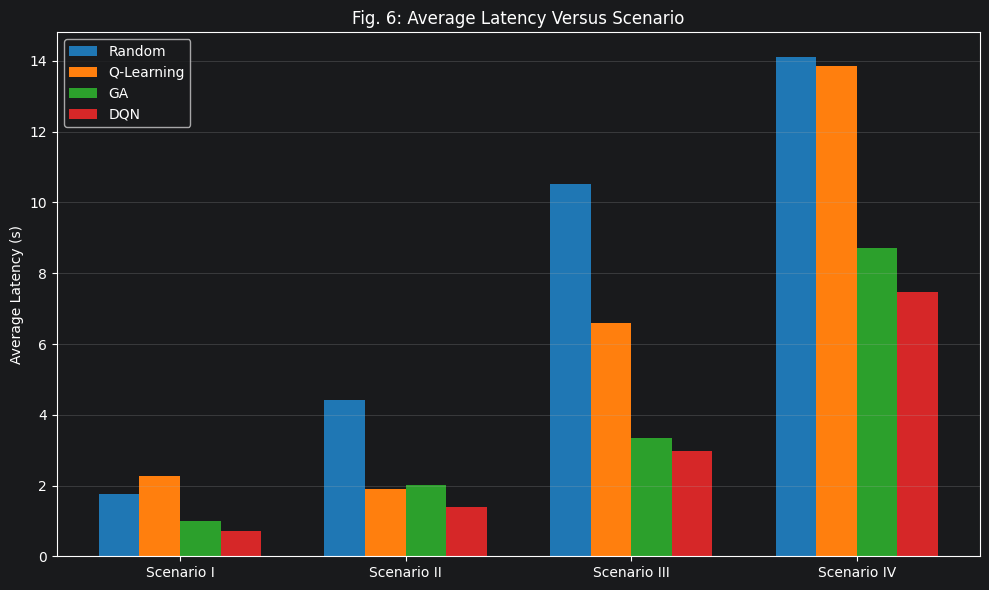

In [20]:
# ═════════════════════════════════════════════════════════════════════
# Experiment 3: Scenario Comparison (Fig. 6)
# ═════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("Experiment 3: Scenario Comparison (Fig. 6)")
print("=" * 60)

scenario_results = {}
for sc in ["I", "II", "III", "IV"]:
    print(f"\n  --- Scenario {sc} ---")
    env_sc = MECEnvironment(num_devices, scenario=sc, task_density=30)
    agent_sc, _, _ = train_dqn(
        env_sc, num_epochs=200, steps_per_epoch=30, verbose=True,
    )
    sc_res = evaluate_all_schemes(
        agent_sc, scenario=sc, num_devices=num_devices,
        task_density=30, num_runs=3,
    )
    scenario_results[sc] = sc_res
    print(f"  Results: {{{', '.join([f'{k}: {v:.4f}' for k, v in sc_res.items()])}}}")

plot_scenario_comparison(scenario_results)


Experiment 4: Density Comparison (Fig. 7)

  --- Density = 20 ---
    Epoch 50/200  Loss: 1.6662  Reward: -48.77  ε: 0.2181
    Epoch 100/200  Loss: 2.5234  Reward: -42.44  ε: 0.0476
    Epoch 150/200  Loss: 1.5781  Reward: -29.44  ε: 0.0104
    Epoch 200/200  Loss: 1.2095  Reward: -27.40  ε: 0.0100
  Results: {Random: 3.8168, Q-Learning: 5.2801, GA: 1.9071, DQN: 1.2729}

  --- Density = 25 ---
    Epoch 50/200  Loss: 1.2331  Reward: -63.72  ε: 0.2181
    Epoch 100/200  Loss: 2.2461  Reward: -43.12  ε: 0.0476
    Epoch 150/200  Loss: 1.5907  Reward: -41.33  ε: 0.0104
    Epoch 200/200  Loss: 1.0756  Reward: -40.12  ε: 0.0100
  Results: {Random: 4.3689, Q-Learning: 4.4836, GA: 2.3068, DQN: 1.3997}

  --- Density = 30 ---
    Epoch 50/200  Loss: 1.2729  Reward: -81.84  ε: 0.2181
    Epoch 100/200  Loss: 1.7780  Reward: -52.21  ε: 0.0476
    Epoch 150/200  Loss: 1.3403  Reward: -47.04  ε: 0.0104
    Epoch 200/200  Loss: 1.1857  Reward: -49.10  ε: 0.0100
  Results: {Random: 5.1601, Q-Lear

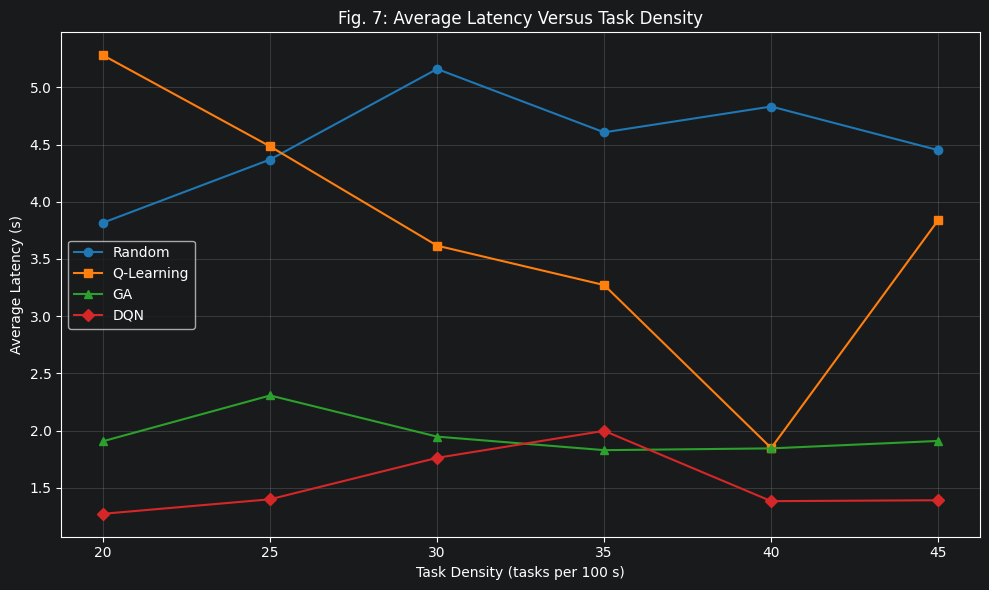

In [21]:
# ═════════════════════════════════════════════════════════════════════
# Experiment 4: Density Comparison (Fig. 7)
# ═════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("Experiment 4: Density Comparison (Fig. 7)")
print("=" * 60)

density_results = {}
for density in [20, 25, 30, 35, 40, 45]:
    print(f"\n  --- Density = {density} ---")
    env_d = MECEnvironment(density, scenario="II", task_density=density)
    agent_d, _, _ = train_dqn(
        env_d, num_epochs=200, steps_per_epoch=30, verbose=True,
    )
    d_res = evaluate_all_schemes(
        agent_d, scenario="II", num_devices=density,
        task_density=density, num_runs=3,
    )
    density_results[density] = d_res
    print(f"  Results: {{{', '.join([f'{k}: {v:.4f}' for k, v in d_res.items()])}}}")

plot_density_comparison(density_results)

In [22]:
# ═════════════════════════════════════════════════════════════════════
# COMPLETION
# ═════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("All experiments complete!")
print("=" * 60)



All experiments complete!
